In [2]:
import torch
import torch.nn as nn
import numpy as np
import networkx as nx
import torch.optim as optim
import torch.nn.functional as F
import pandas as pd
import os

In [4]:
edge_dir = os.path.join(os.getcwd(), 'Ex17', 'lab2', 'lab2_edgelist.txt')
attribute_dir = os.path.join(os.getcwd(), 'Ex17', 'lab2', 'lab2_attributes.csv')
attributes = pd.read_csv(attribute_dir)

In [11]:
attributes.set_index('node', inplace = True)

In [12]:
attributes.head(5)

,role,community
node,,
0,Administrator,Administrator
1,Member,Administrator
2,Member,Administrator
3,Member,Administrator
4,Member,Administrator


In [43]:
attributes['role'].value_counts()

role
Member           32
Administrator     1
Instructor        1
Name: count, dtype: int64

In [44]:
nx.to_numpy_array(g)

array([[0., 1., 1., ..., 0., 0., 0.],
       [1., 0., 1., ..., 0., 0., 0.],
       [1., 1., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 1., 0., 0.]], shape=(34, 34))

In [18]:
for index,_ in enumerate(attributes.values):
    print(index)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33


In [ ]:
g = nx.read_edgelist(edge_dir,nodetype=int)

In [26]:
nodes = list(g.nodes())
nodes.sort()
print(nodes)

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33]


In [45]:
def create_graphs_with_attributes(edgelist_filepath,attributes_filepath):
    graph=nx.read_edgelist(edgelist_filepath,nodetype=int)
    attributes=pd.read_csv(attributes_filepath,index_col=['node'])
    att_values = {a:{'role':b[0],'community':b[1]} for a,b in enumerate(attributes.values)}
    nx.set_node_attributes(graph,att_values)
    return graph


def create_train_test(graph):
    X_train,Y_train,X_test,Y_test=[],[],[],[]
    for node, data in graph.nodes(data=True):
        if data['role'] in ['Administrator','Instructor']:
            X_train.append(node)
            Y_train.append(data['role']=='Administrator')
        elif data['role'] =='Member':
            X_test.append(node)
            Y_test.append(data['community']=='Administrator')
    return np.asarray(X_train),np.asarray(Y_train),np.asarray(X_test),np.asarray(Y_test)



def create_features(graph): # create input features, concatenation of identity matrix and shortest paths to targets
    A = nx.to_numpy_array(graph)
    X_1 = torch.eye(A.shape[0]) # identity matrix
    X_2 = torch.zeros((A.shape[0], 2)) # shortest path to the targets as 2nd input feature
    node_distance_instructor = nx.shortest_path_length(graph, target=33)
    node_distance_administrator = nx.shortest_path_length(graph, target=0)

    for node in graph.nodes():
        X_2[node][0] = node_distance_administrator[node]
        X_2[node][1] = node_distance_instructor[node]

    return torch.cat((X_1,X_2),dim=1)    
    # có tất cả 34 node, X_1 có shape là 34,34 X_2 có shape là 34,2, output cuối là 34,36


In [29]:
g = create_graphs_with_attributes(edge_dir, attribute_dir)

In [39]:
g.nodes(data = True)

NodeDataView({0: {'role': 'Administrator', 'community': 'Administrator'}, 1: {'role': 'Member', 'community': 'Administrator'}, 2: {'role': 'Member', 'community': 'Administrator'}, 3: {'role': 'Member', 'community': 'Administrator'}, 4: {'role': 'Member', 'community': 'Administrator'}, 5: {'role': 'Member', 'community': 'Administrator'}, 6: {'role': 'Member', 'community': 'Administrator'}, 7: {'role': 'Member', 'community': 'Administrator'}, 8: {'role': 'Member', 'community': 'Administrator'}, 10: {'role': 'Member', 'community': 'Administrator'}, 11: {'role': 'Member', 'community': 'Administrator'}, 12: {'role': 'Member', 'community': 'Administrator'}, 13: {'role': 'Member', 'community': 'Administrator'}, 17: {'role': 'Member', 'community': 'Administrator'}, 19: {'role': 'Member', 'community': 'Administrator'}, 21: {'role': 'Member', 'community': 'Administrator'}, 31: {'role': 'Member', 'community': 'Instructor'}, 30: {'role': 'Member', 'community': 'Instructor'}, 9: {'role': 'Member', 

In [ ]:
from torch.nn.parameter import Parameter

class GCN_layer(nn.Module):
    """
      Define filter layer 1/2 like in the above image
      Calculate A_hat first then,
      Input: adj_matrix with input features X
    """   

    def __init__(self, inputs_shape, outputs_shape):
        super(GCN_layer, self).__init__()

        self.W=Parameter(torch.rand(inputs_shape,outputs_shape),requires_grad=True)
        self.bias = Parameter(torch.rand(outputs_shape),requires_grad=True)

    
    def forward(self, adj_matrix, input_features):
        # Calculate A_hat: adjacency matrix with self-loops, normalized
        A_hat = torch.tensor(adj_matrix).float()
        I = torch.eye(A_hat.shape[0])
        A_hat = A_hat + I
        
        # Normalize: D^-1/2 * A * D^-1/2
        D = torch.diag(torch.sum(A_hat, dim=1))
        D_inv_sqrt = torch.linalg.inv(torch.sqrt(D + 1e-6))
        A_hat = torch.mm(torch.mm(D_inv_sqrt, A_hat), D_inv_sqrt)
        
        aggregate=torch.mm(A_hat,input_features)  # shape là n, n+2     
        propagate=torch.mm(aggregate,self.W)+self.bias     # n, output shape    
        return propagate

* D là ma trận bậc cho biết số bậc của mỗi node, để tính được ma trận bậc ta tính tổng ma trận kề theo hàng rồi lấy các giá trị đó làm đường chéo của 1 tensor 0
* D có chiều là N*N, nên nghịch đảo của D cũng có chiều tương tự
* A hat là A sau khi đã được cộng thêm ma trận đơn vị (trong ma trận kề thì đường chéo chính luôn là 0), cũng có chiều là N,N
* Đầu tiên là chuẩn hóa A lấy được A hat sau đó sử dụng A hat nhân với đầu vào X (34, 36), sau đó lấy giá trị này đi qua 1 lớp tuyến tính
* Ta có tính chất là nếu lấy 1 ma trận đường chéo nhân với 1 ma trận X nếu ma trận đường chéo đứng bên trái thì ma trận mới có kết quả là áp dụng phép chia từng phần tử trên từng hàng của ma trận X với phần tử tương ứng bên ma trận đường chéo. còn nếu ma trận đường chéo đặt bên phải của ma trận X thì áp dựng tương tự nhưng lên các cột tương ứng

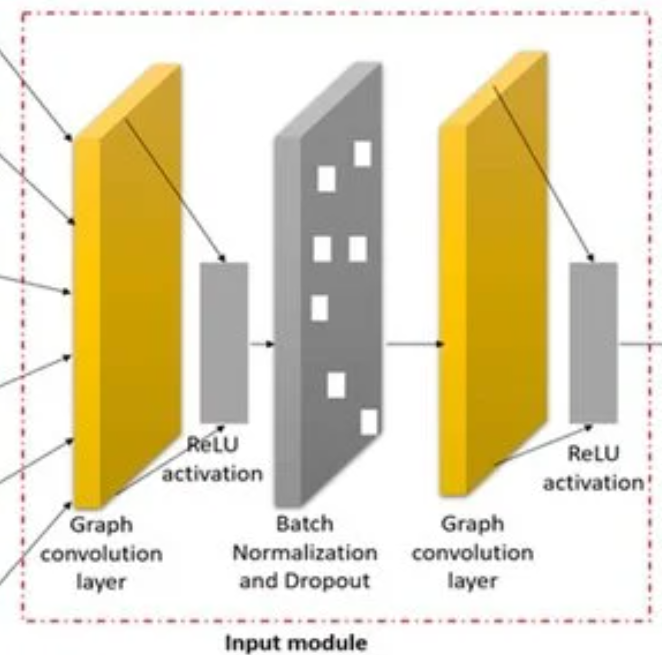

In [26]:
class GCN(nn.Module):
    

    def __init__(self,inputs_shape,outputs_shape,n_classes,activation='Relu'):
        super(GCN, self).__init__()

        self.layer1=GCN_layer(inputs_shape,outputs_shape)
        self.layer2=GCN_layer(outputs_shape,n_classes)
        
        
        if activation =='Tanh':
            self.activation = nn.Tanh()
        elif activation=='Sigmoid':
            self.activation = nn.Sigmoid()
        elif activation=='Softmax':
            self.activation=nn.Softmax()
        elif activation=='Relu':
            self.activation=nn.ReLU()
    
        self.softmax=nn.Softmax()
        
    
    def forward(self,adj_matrix,input_features):
        # Define output for each layer
        x = self.layer1(adj_matrix, input_features)
        x = self.activation(x)
        x = self.layer2(adj_matrix, x)
        x = self.softmax(x)
        
        return x

In [27]:
import torch
from sklearn.metrics import classification_report
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import networkx as nx
import os

edge_dir = os.path.join(os.getcwd(), 'Ex17', 'lab2', 'lab2_edgelist.txt')
attribute_dir = os.path.join(os.getcwd(), 'Ex17', 'lab2', 'lab2_attributes.csv')

graph=create_graphs_with_attributes(edge_dir,attribute_dir)
A = nx.to_numpy_array(graph) # adjadjency matrix 

class Trainer():
    def __init__(self,model,optimizer,loss_function,epochs):
        
        self.model=model
        self.optimizer=optimizer
        self.loss_function=loss_function
        self.epochs=epochs
        
    def train(self,X_train,Y_train):

        y_train=torch.from_numpy(Y_train.astype(int)).type(torch.LongTensor)
        tot_loss=0.0
        all_preds=[]

        for t in range(self.epochs):
            epoch_loss = 0.0

            #model.train()
            y_pred=self.model(A, create_features(graph))
            all_preds.append(y_pred)
            loss = self.loss_function(y_pred[X_train], y_train)
            self.optimizer.zero_grad()
            epoch_loss+=loss
            tot_loss+=loss
            loss.backward()
            self.optimizer.step()

            print(str(t),'epoch_loss:'+str(epoch_loss),'total loss:'+str(tot_loss))

        self.all_preds=all_preds
    
    def test(self,X_test,Y_test):

        self.model.eval()
        y_test=torch.from_numpy(Y_test.astype(int)).type(torch.LongTensor)
        y_pred=self.all_preds[-1]  # preds of last epoch
        loss_test = self.loss_function(y_pred[X_test],y_test)
        print('validation loss is equal to: '+str(loss_test))
    
    def visualize_classification(self,graph,Y_test,classification):
        last_epoch = self.all_preds[self.epochs-1].detach().numpy() # get outputs of last epoch
        predicted_class = np.argmax(last_epoch, axis=-1) # take the unit with the higher probability
        color = np.where(predicted_class==0, 'c', 'r')
        pos = nx.kamada_kawai_layout(graph)
        nx.draw_networkx(graph, pos, node_color=color, with_labels=True, node_size=300)
        if classification==True:
            print(classification_report(predicted_class[1:-1],Y_test))

c:\Weekly_Hw_GR1\venv\Lib\site-packages\torch\nn\modules\module.py:1779: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


0 epoch_loss:tensor(0.6165, grad_fn=<AddBackward0>) total loss:tensor(0.6165, grad_fn=<AddBackward0>)
1 epoch_loss:tensor(0.6055, grad_fn=<AddBackward0>) total loss:tensor(1.2220, grad_fn=<AddBackward0>)
2 epoch_loss:tensor(0.5979, grad_fn=<AddBackward0>) total loss:tensor(1.8199, grad_fn=<AddBackward0>)
3 epoch_loss:tensor(0.5936, grad_fn=<AddBackward0>) total loss:tensor(2.4135, grad_fn=<AddBackward0>)
4 epoch_loss:tensor(0.5903, grad_fn=<AddBackward0>) total loss:tensor(3.0038, grad_fn=<AddBackward0>)
5 epoch_loss:tensor(0.5861, grad_fn=<AddBackward0>) total loss:tensor(3.5899, grad_fn=<AddBackward0>)
6 epoch_loss:tensor(0.5807, grad_fn=<AddBackward0>) total loss:tensor(4.1706, grad_fn=<AddBackward0>)
7 epoch_loss:tensor(0.5744, grad_fn=<AddBackward0>) total loss:tensor(4.7450, grad_fn=<AddBackward0>)
8 epoch_loss:tensor(0.5676, grad_fn=<AddBackward0>) total loss:tensor(5.3126, grad_fn=<AddBackward0>)
9 epoch_loss:tensor(0.5608, grad_fn=<AddBackward0>) total loss:tensor(5.8734, grad

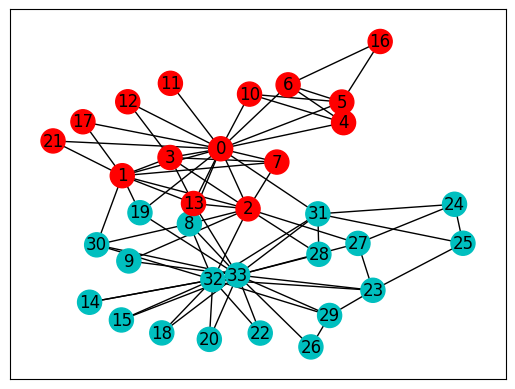

In [28]:
graph=create_graphs_with_attributes(edge_dir, attribute_dir)
A = nx.to_numpy_array(graph)
X_train,Y_train,X_test,Y_test= create_train_test(graph)

model=GCN(inputs_shape=create_features(graph).shape[1],outputs_shape=4,n_classes=2,activation='Relu')
trainer = Trainer(
    model,
    optimizer = optim.Adam(model.parameters(), lr=0.01),
    loss_function=F.cross_entropy,
    epochs=250
)

trainer.train(X_train,Y_train)
trainer.test(X_test,Y_test)
trainer.visualize_classification(graph,Y_test,classification=True)